# Per-cluster eigen decomposition of SEAM attribution maps

For a single reference sequence (default **peak84030**) we take every available SEAM run
(different library sizes / k-means cluster counts) and, for the **WT cluster** of each run,
treat the per-sequence SEAM attribution maps as observations:

- each member sequence of the cluster = one observation
- each (position x channel) = a feature (200 x 4 = 800 features)

We decompose the stacked maps **without observation-centering** (the attribution origin is a
meaningful reference, so the shared consensus map is signal — see the methods cell below).
Outputs:

1. **cluster cleanliness** = mode-1 variance fraction for every SEAM run of the ref seq
   (near 1 = every member shares one consensus map)
2. the **consensus mode (mode 1)** rendered as a sequence logo per run, plus **modes 1-3**
   (consensus + leading departures) for one focal run

In [90]:
import numpy as np, matplotlib.pyplot as plt, h5py, sys
from pathlib import Path

# Pablo's fast_logo renderer for attribution (L,4) logos
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
OUT = Path("/grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results")

REF_SEQ = "peak27535_Reversed"     # single reference sequence; all SEAM runs below are for this seq

# ---- discover every SEAM run available for REF_SEQ -------------------------------------
# a "run" = a foregrounds* clustering dir that has REF_SEQ + its matching library/ISM store.
# dir prefix -> library: 100k/_200k/_300k are @10% mut; _mut5 / _mut5_200k / _mut5_300k are @5%.
# check the most specific (mut5_200k/300k) prefixes first so they don't fall through to _mut5 / _200k.
def lib_suffix(fg_name):
    if fg_name.startswith("foregrounds_mut5_200k"): return "_mut5_200k"   # 200k @5%
    if fg_name.startswith("foregrounds_mut5_300k"): return "_mut5_300k"   # 300k @5%
    if fg_name.startswith("foregrounds_mut5"):      return "_mut5"        # 100k @5%
    if fg_name.startswith("foregrounds_200k"):      return "_200k"        # 200k @10%
    if fg_name.startswith("foregrounds_300k"):      return "_300k"        # 300k @10%
    return ""                                                             # 100k @10%
LIB_LABEL = {"": "100k", "_200k": "200k", "_300k": "300k",
             "_mut5": "mut5", "_mut5_200k": "mut5-200k", "_mut5_300k": "mut5-300k"}

runs = []
for fg in sorted(p.name for p in R.glob("foregrounds*") if p.is_dir()):
    fg_dir = R / fg / REF_SEQ
    suf    = lib_suffix(fg)
    ism_h5 = R / f"ism{suf}" / f"{REF_SEQ}.h5"
    if not (fg_dir / "cluster_labels.npy").exists() or not ism_h5.exists():
        continue
    labels   = np.load(fg_dir / "cluster_labels.npy")
    lib_size = LIB_LABEL[suf]
    runs.append(dict(fg_name=fg, fg_dir=fg_dir, ism_h5=ism_h5, suffix=suf,
                     lib_size=lib_size, n_clusters=len(np.unique(labels)),
                     label=f"{lib_size}_k{len(np.unique(labels))}"))

# ---- random-clustering baseline --------------------------------------------------------
# shuffle labels: assign every library sequence to a random cluster, matched to the 100k_k100
# run (same library + same #clusters). A "cluster" is now a random subset, so its mode-1
# fraction is the null baseline you'd get with no real structure.
base = next((r for r in runs if r["label"] == "100k_k100"), runs[0])
n_lib = len(np.load(base["fg_dir"] / "cluster_labels.npy"))
rand_labels = np.random.default_rng(0).integers(0, base["n_clusters"], size=n_lib).astype(np.int32)
runs.append(dict(fg_name="RANDOM", fg_dir=None, ism_h5=base["ism_h5"], suffix=base["suffix"],
                 lib_size=base["lib_size"], n_clusters=base["n_clusters"],
                 label=f"random_k{base['n_clusters']}", random_labels=rand_labels))

print(f"{len(runs)} run(s) for {REF_SEQ} (incl. 1 random baseline):")
for r in runs:
    print(f"  {r['label']:14s}  {r['fg_name']}  (ism{r['suffix']}/, {r['n_clusters']} clusters)")

20 run(s) for peak27535_Reversed (incl. 1 random baseline):
  100k_k50        foregrounds  (ism/, 50 clusters)
  200k_k100       foregrounds_200k  (ism_200k/, 100 clusters)
  200k_k150       foregrounds_200k_kmeans150  (ism_200k/, 150 clusters)
  200k_k200       foregrounds_200k_kmeans200  (ism_200k/, 200 clusters)
  200k_k300       foregrounds_200k_kmeans300  (ism_200k/, 300 clusters)
  300k_k50        foregrounds_300k  (ism_300k/, 50 clusters)
  300k_k100       foregrounds_300k_kmeans100  (ism_300k/, 100 clusters)
  300k_k200       foregrounds_300k_kmeans200  (ism_300k/, 200 clusters)
  300k_k300       foregrounds_300k_kmeans300  (ism_300k/, 300 clusters)
  300k_k400       foregrounds_300k_kmeans400  (ism_300k/, 400 clusters)
  100k_k100       foregrounds_kmeans100  (ism/, 100 clusters)
  100k_k200       foregrounds_kmeans200  (ism/, 200 clusters)
  100k_k250       foregrounds_kmeans250  (ism/, 250 clusters)
  100k_k300       foregrounds_kmeans300  (ism/, 300 clusters)
  100k_k350   

## Eigen decomposition per WT cluster (uncentered)

For each run, the WT reference is row 0 of the mutagenesis library, so its cluster is
`cluster_labels[0]`. We pull the ISM-centered attribution maps of every member of that
cluster and flatten to `(n_members, 800)`.

We deliberately **do not observation-center** (no mean subtraction across members): the
attribution origin (0 = no contribution) is a meaningful physical reference, so the shared
cluster-mean map is signal, not an offset to remove. We take the SVD of the raw stacked
maps. **Mode 1 is the shared consensus map**, and its variance fraction
`S[0]**2 / sum(S**2)` is a **cluster-cleanliness / collinearity score** — high (near 1)
means every member tells the same story. Modes 2, 3, ... are the leading *departures* from
that consensus (they equal the mean-centered PCA modes). Mode signs are arbitrary; we orient
each toward the WT cluster-average map.

In [91]:
import pickle

# per-run cache keyed by run label: only runs missing from the cache are computed (each SVD
# reloads big ISM slices), so adding a new run (e.g. mut5) computes just that one.
# set RECOMPUTE = True to force a full recompute of every run.
CACHE     = OUT / f"{REF_SEQ}_decomp.pkl"
RECOMPUTE = False

def _orient(vec, ref):
    # deterministic sign: align with the cluster-mean map when they overlap, else make the peak positive
    s = float(np.sum(vec * ref))
    if abs(s) > 1e-8:
        return vec if s >= 0 else -vec
    return vec if vec.flat[np.argmax(np.abs(vec))] >= 0 else -vec

def _decomp(r):
    labels = r.get("random_labels")                          # random baseline carries its own labels
    if labels is None:
        labels = np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_cluster = int(labels[0]); members = np.where(labels == wt_cluster)[0]
    with h5py.File(r["ism_h5"]) as f:
        maps = f["ism_centered"][members]                    # (M, 200, 4)
    M = len(members)
    X = maps.reshape(M, -1).astype(np.float64)               # uncentered: shared mean counts as variance
    _, S, Vt = np.linalg.svd(X, full_matrices=False)
    frac = S ** 2 / np.sum(S ** 2)
    ref_avg = maps.mean(0) if r["fg_dir"] is None else np.load(r["fg_dir"] / "ref_cluster_avg.npy")
    modes = [_orient(Vt[k].reshape(200, 4), ref_avg) for k in range(3)]
    return dict(label=r["label"], fg_name=r["fg_name"], wt_cluster=wt_cluster, n_members=M,
                cleanliness=float(frac[0]), frac=frac[:3].astype(float), modes=modes,
                is_random=r["fg_dir"] is None)

cache = {} if (RECOMPUTE or not CACHE.exists()) else pickle.load(open(CACHE, "rb"))
if isinstance(cache, list):                                  # migrate old list-format cache -> dict by label
    cache = {d["label"]: d for d in cache}

n_new = 0
for r in runs:
    if r["label"] not in cache:
        cache[r["label"]] = _decomp(r); n_new += 1
        d = cache[r["label"]]
        print(f"computed {r['label']:12s}  ({d['n_members']:6d} seqs)  mode1={d['cleanliness']:.3f}")
if n_new:
    pickle.dump(cache, open(CACHE, "wb"))
    print(f"cached {n_new} new run(s) -> {CACHE.name}")
else:
    print(f"all {len(runs)} runs loaded from cache ({CACHE.name})")

results = sorted((cache[r["label"]] for r in runs), key=lambda d: (d["is_random"], d["label"]))

all 20 runs loaded from cache (peak27535_Reversed_decomp.pkl)


## 1. Cluster cleanliness (mode-1 variance fraction) across all SEAM runs

Uncentered mode-1 fraction: near 1 = every member shares the same consensus map (clean/tight
cluster); lower = variance splits into secondary modes (heterogeneous cluster).

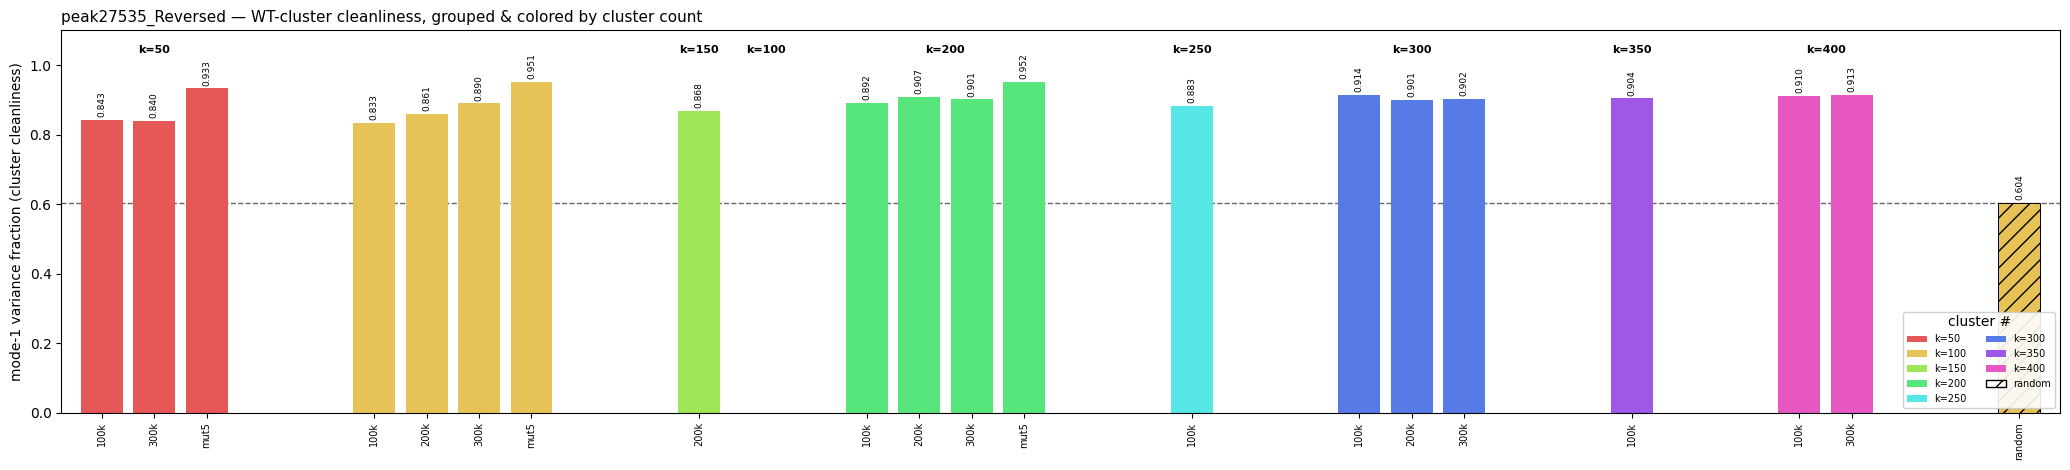

In [92]:
import colorsys
from matplotlib.patches import Patch

def kof(d):   return int(d["label"].split("_k")[-1])       # cluster count from label
def libof(d): return d["label"].split("_k")[0]             # library tag (100k/200k/300k/mut5/random)

# group runs by cluster number k (same k adjacent, library sorted within); random baseline last
order  = sorted(results, key=lambda d: (d["is_random"], kof(d), libof(d)))
# one unique color per cluster count (HSV-spaced so it never recycles as k-values grow)
ks     = sorted({kof(d) for d in order})
kcolor = {k: colorsys.hsv_to_rgb(i / len(ks), 0.62, 0.90) for i, k in enumerate(ks)}

# x positions with a wide gap between k-groups so group headers never collide
GAP = 2.2
xs, x, prevk = [], 0, None
for d in order:
    if prevk is not None and kof(d) != prevk: x += GAP
    xs.append(x); x += 1; prevk = kof(d)

fig, ax = plt.subplots(figsize=(max(7, 0.5 * x + 2), 4.8))
for xi, d in zip(xs, order):
    ax.bar(xi, d["cleanliness"], color=kcolor[kof(d)],
           hatch="//" if d["is_random"] else None,
           edgecolor="black" if d["is_random"] else "none", linewidth=0.7)
    ax.text(xi, d["cleanliness"] + 0.008, f"{d['cleanliness']:.3f}",
            ha="center", va="bottom", fontsize=6.5, rotation=90)
rand = next((d["cleanliness"] for d in order if d["is_random"]), None)
if rand is not None:
    ax.axhline(rand, color="0.4", lw=1, ls="--", zorder=0)

ax.set_xticks(xs)
ax.set_xticklabels([libof(d) for d in order], rotation=90, fontsize=7)
for k in ks:                                                # one centered header per k-group
    gx = [xi for xi, d in zip(xs, order) if kof(d) == k]
    ax.text(np.mean(gx), 1.03, f"k={k}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("mode-1 variance fraction (cluster cleanliness)")
ax.set_ylim(0, 1.10)
ax.margins(x=0.01)
ax.legend(handles=[Patch(facecolor=kcolor[k], label=f"k={k}") for k in ks] +
                  [Patch(facecolor="white", edgecolor="black", hatch="//", label="random")],
          title="cluster #", fontsize=7, ncol=2, loc="lower right", framealpha=0.9)
ax.set_title(f"{REF_SEQ} — WT-cluster cleanliness, grouped & colored by cluster count", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_cluster_cleanliness.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Consensus mode (mode 1) as a sequence logo per run

One logo per SEAM run: the uncentered mode-1 eigenvector = the shared consensus attribution
map of the WT cluster (full 4 channels). (Leading departures — modes 2 & 3 — for one focal
run are shown in the next cell.)

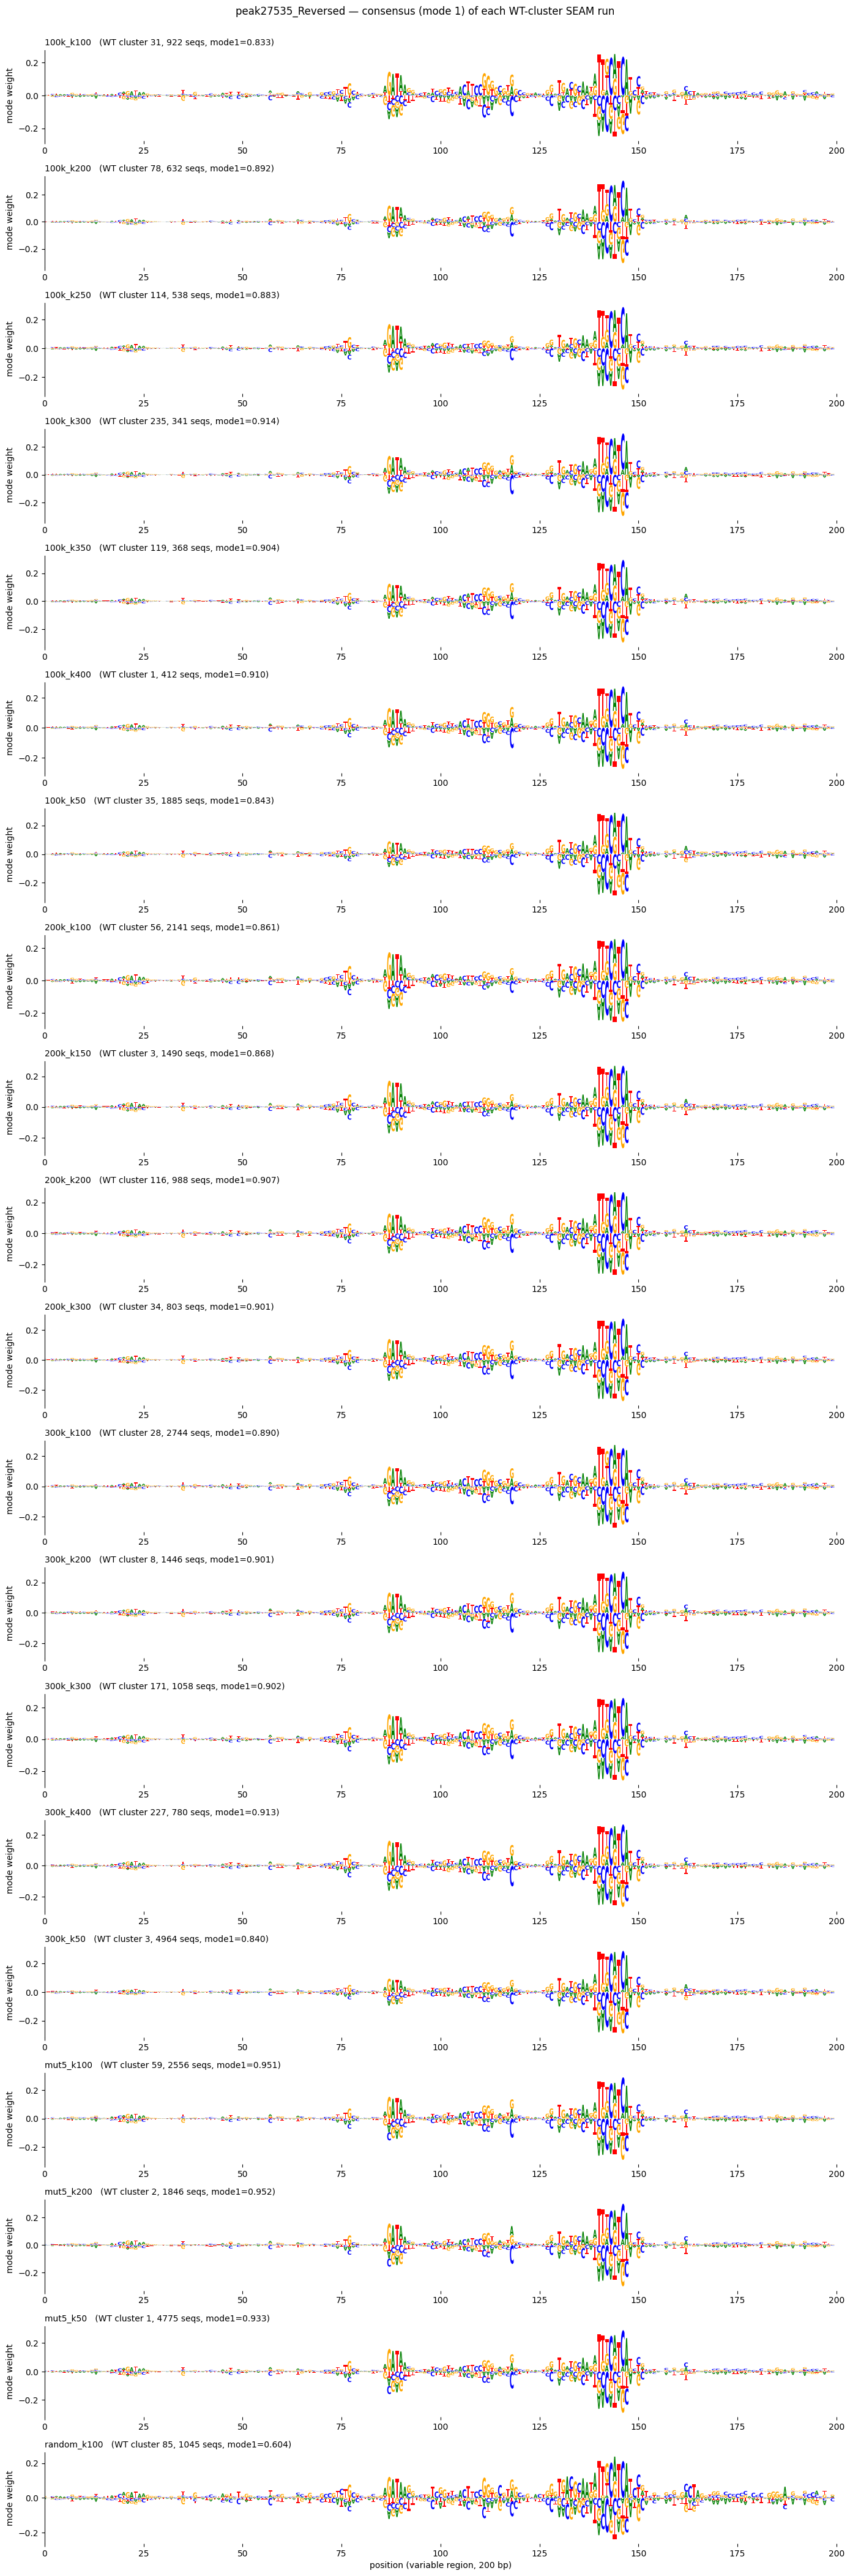

In [93]:
n = len(results)
# sharex=False so every logo is on its own scale (fast_logo auto-fits y per panel)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.1 * n), sharex=False, squeeze=False)
for ax, d in zip(axes[:, 0], results):
    fast_logo(d["modes"][0], ax)                               # (200,4) mode-1 = consensus map
    ax.set_title(f"{d['label']}   (WT cluster {d['wt_cluster']}, {d['n_members']} seqs, "
                 f"mode1={d['cleanliness']:.3f})", loc="left", fontsize=10)
    ax.set_ylabel("mode weight")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — consensus (mode 1) of each WT-cluster SEAM run", y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_consensus_mode_logos.png", dpi=150, bbox_inches="tight")
plt.show()

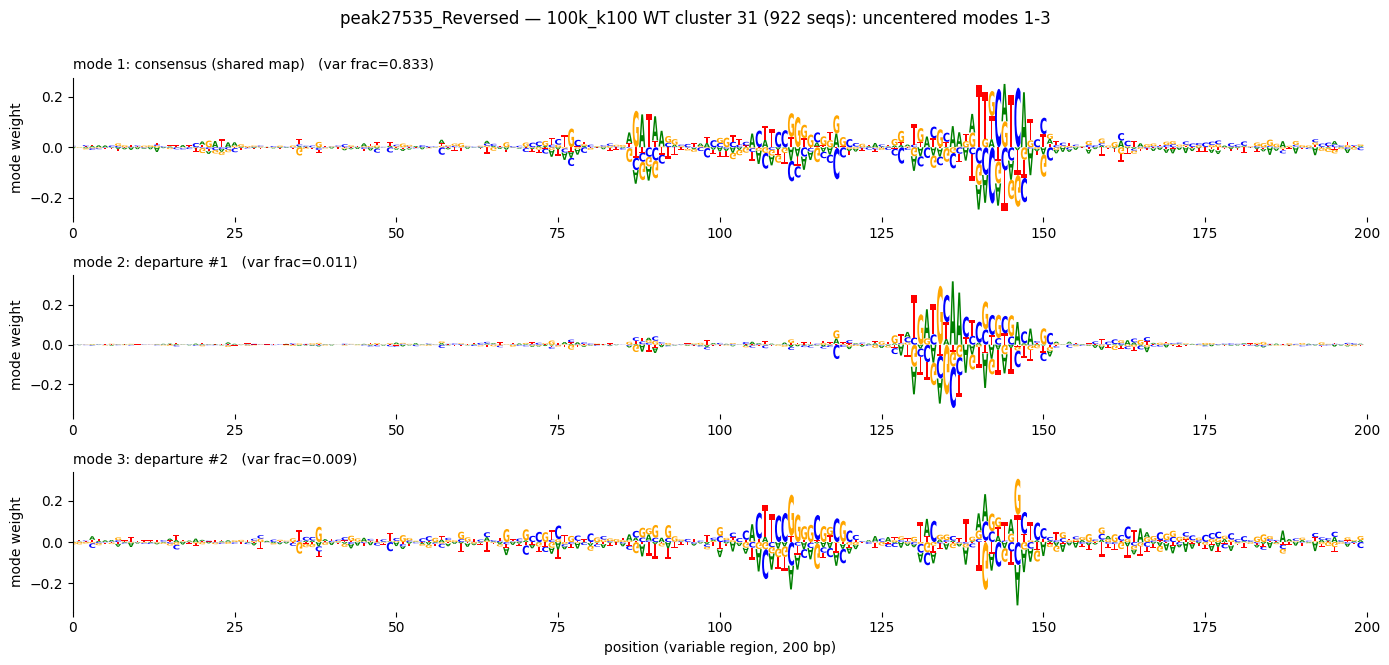

In [94]:
# consensus + leading departures for one focal run: uncentered modes 1-3
FOCUS = "100k_k100"
d = next(x for x in results if x["label"] == FOCUS)

names = ["consensus (shared map)", "departure #1", "departure #2"]
fig, axes = plt.subplots(3, 1, figsize=(14, 6.6), sharex=False)   # each mode on its own scale
for ax, k in zip(axes, range(3)):
    fast_logo(d["modes"][k], ax)                               # mode k as (200,4)
    ax.set_title(f"mode {k+1}: {names[k]}   (var frac={d['frac'][k]:.3f})", loc="left", fontsize=10)
    ax.set_ylabel("mode weight")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — {FOCUS} WT cluster {d['wt_cluster']} ({d['n_members']} seqs): "
             f"uncentered modes 1-3", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_{FOCUS}_modes123.png", dpi=150, bbox_inches="tight")
plt.show()

best run: mut5_k200  (foregrounds_mut5_kmeans200, cleanliness=0.952)


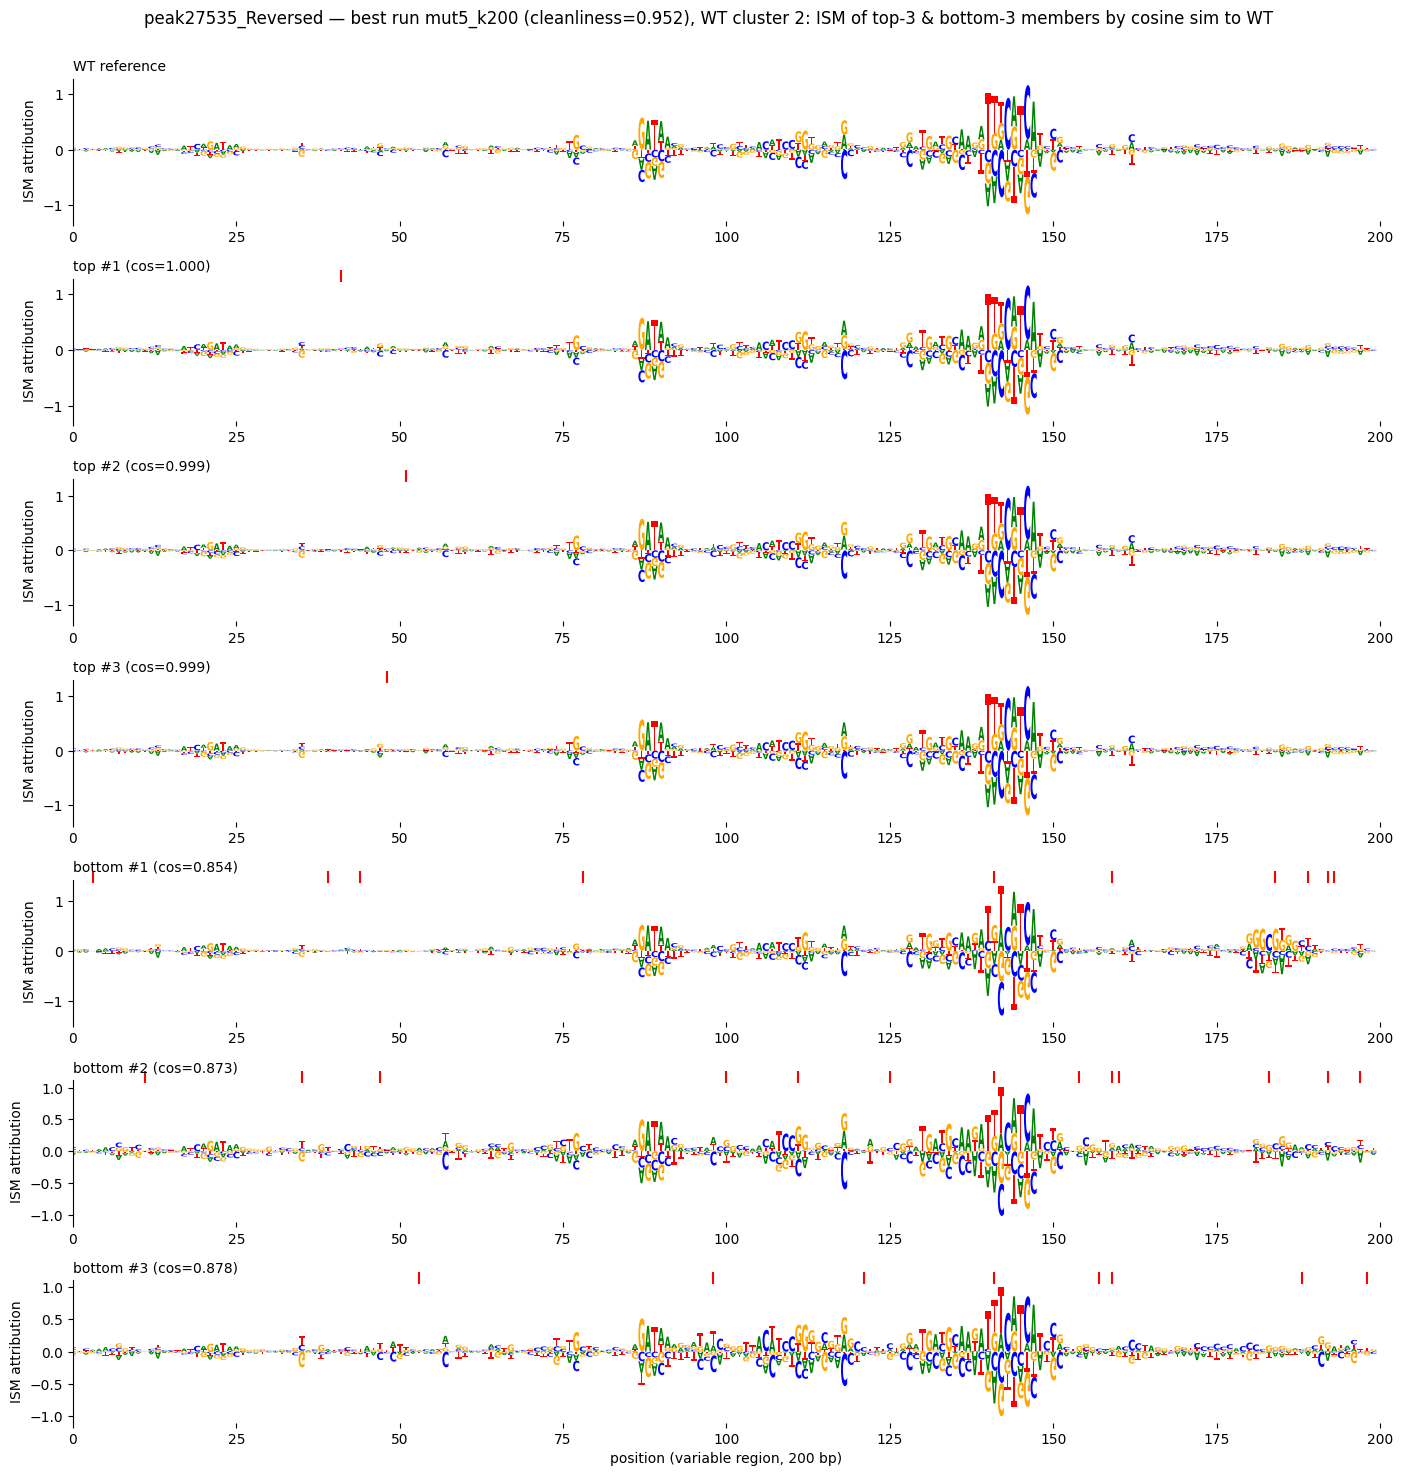

In [95]:
# FINAL: best-performing run (largest cleanliness, excluding the random baseline) ->
# ISM maps of its top-3 and bottom-3 WT-cluster members by cosine sim to WT.
best = max((d for d in results if not d["is_random"]), key=lambda d: d["cleanliness"])
suf  = lib_suffix(best["fg_name"])
ISM_H5, LIB_H5 = R / f"ism{suf}" / f"{REF_SEQ}.h5", R / f"mutagenesis_lib{suf}" / f"{REF_SEQ}.h5"
print(f"best run: {best['label']}  ({best['fg_name']}, cleanliness={best['cleanliness']:.3f})")

labels     = np.load(R / best["fg_name"] / REF_SEQ / "cluster_labels.npy")
wt_cluster = int(labels[0])                                   # WT reference = library row 0
with h5py.File(ISM_H5) as f:
    attributions = f["ism_centered"][:]                       # (N, 200, 4) ISM maps
with h5py.File(LIB_H5) as f:
    var_seqs = f["sequences"][:, 15:215, :]                   # (N, 200, 4) variable-region one-hot

wt_map     = attributions[0]                                  # WT ISM map
wt_int     = var_seqs[0].argmax(-1)                           # WT bases
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)          # differs from WT (excludes idx0 + exact-WT dupes)

members = np.where(labels == wt_cluster)[0]
members = members[is_variant[members]]                        # rank variants only; WT shown separately
flat    = attributions[members].reshape(len(members), -1)
cos     = flat @ wt_map.ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(wt_map))
order   = np.argsort(cos)                                     # ascending: low cos = bottom

top     = members[order[-3:][::-1]]; tcos = cos[order[-3:][::-1]]   # top-3 most similar to WT
bottom  = members[order[:3]];        bcos = cos[order[:3]]          # bottom-3 least similar to WT

# (title, seq index, whether to draw red mutation ticks)
panels  = [("WT reference", 0, False)]
panels += [(f"top #{i+1} (cos={c:.3f})",    int(idx), True) for i, (idx, c) in enumerate(zip(top, tcos))]
panels += [(f"bottom #{i+1} (cos={c:.3f})", int(idx), True) for i, (idx, c) in enumerate(zip(bottom, bcos))]

# sharex=False so every logo is on its own scale
fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.1 * len(panels)), sharex=False, squeeze=False)
for ax, (title, idx, tick) in zip(axes[:, 0], panels):
    fast_logo(attributions[idx], ax)                          # raw ISM map, full 4 channels
    if tick:
        mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0] # positions mutated from WT
        ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
                markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("ISM attribution")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — best run {best['label']} (cleanliness={best['cleanliness']:.3f}), WT cluster "
             f"{wt_cluster}: ISM of top-3 & bottom-3 members by cosine sim to WT", y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_bestrun_{best['label']}_top_bottom3_ism.png", dpi=150, bbox_inches="tight")
plt.show()

# Background-subtracted variant

The SEAM maps still contain the **library-wide background** — the WT-motif backbone every
mutant shares — which is why even random clustering scored ~0.6 above. Here we redo the exact
same decomposition, but first subtract SEAM's own scaled background from every member map:

```
foreground_i = ism_i - average_background_scaled          # = ism_i - bg_scale * background
```

`bg_scale` is SEAM's **adaptive per-cluster** scaling factor (from `MetaExplainer`, recovered
here per run and reported). After removing the shared backbone, mode-1 measures the cluster's
*distinctive* shared structure — the random baseline collapses (~0.40) while real clusters stay
high (~0.89).

In [96]:
# same as above but subtract SEAM's WT-cluster scaled background from every member map first:
# fg_i = ism_i - average_background_scaled  (= ism_i - bg_scale * background). Per-run cache keyed
# by label -> only missing runs (e.g. mut5) are computed. bg_scale is SEAM's adaptive factor.
CACHE_BG  = OUT / f"{REF_SEQ}_decomp_bg.pkl"
RECOMPUTE = False
BASE_FG   = R / "foregrounds_kmeans100" / REF_SEQ            # background source for the random baseline

def _decomp_bg(r):
    labels = r.get("random_labels")
    if labels is None:
        labels = np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_cluster = int(labels[0]); members = np.where(labels == wt_cluster)[0]
    with h5py.File(r["ism_h5"]) as f:
        maps = f["ism_centered"][members]                    # (M, 200, 4)
    src = BASE_FG if r["fg_dir"] is None else r["fg_dir"]     # random borrows the base library's bg
    bgs = np.load(src / "average_background_scaled.npy")      # bg_scale * background (WT cluster)
    bg  = np.load(src / "average_background.npy")
    bg_scale = float((bgs * bg).sum() / (bg * bg).sum())      # recover SEAM adaptive scaling factor
    M = len(members)
    X = (maps - bgs).reshape(M, -1).astype(np.float64)        # background-subtracted foreground maps
    _, S, Vt = np.linalg.svd(X, full_matrices=False)
    frac = S ** 2 / np.sum(S ** 2)
    ref_avg = (maps - bgs).mean(0)
    modes = [_orient(Vt[k].reshape(200, 4), ref_avg) for k in range(3)]
    return dict(label=r["label"], fg_name=r["fg_name"], wt_cluster=wt_cluster, n_members=M,
                cleanliness=float(frac[0]), frac=frac[:3].astype(float), modes=modes,
                bg_scale=bg_scale, is_random=r["fg_dir"] is None)

cache = {} if (RECOMPUTE or not CACHE_BG.exists()) else pickle.load(open(CACHE_BG, "rb"))
if isinstance(cache, list):                                  # migrate old list-format cache -> dict by label
    cache = {d["label"]: d for d in cache}

n_new = 0
for r in runs:
    if r["label"] not in cache:
        cache[r["label"]] = _decomp_bg(r); n_new += 1
        d = cache[r["label"]]
        print(f"computed {r['label']:12s}  bg_scale={d['bg_scale']:.3f}  mode1={d['cleanliness']:.3f}")
if n_new:
    pickle.dump(cache, open(CACHE_BG, "wb"))
    print(f"cached {n_new} new run(s) -> {CACHE_BG.name}")
else:
    print(f"all {len(runs)} runs loaded from cache ({CACHE_BG.name})")

results_bg = sorted((cache[r["label"]] for r in runs), key=lambda d: (d["is_random"], d["label"]))

all 20 runs loaded from cache (peak27535_Reversed_decomp_bg.pkl)


## 1b. Cluster cleanliness (background-subtracted) across all SEAM runs

Same mode-1 fraction, computed after subtracting `bg_scale x background` from every member map.
Removing the shared backbone drops the random baseline (~0.6 -> ~0.4) while real clusters stay
high. `bg_scale` is annotated at the base of each bar.

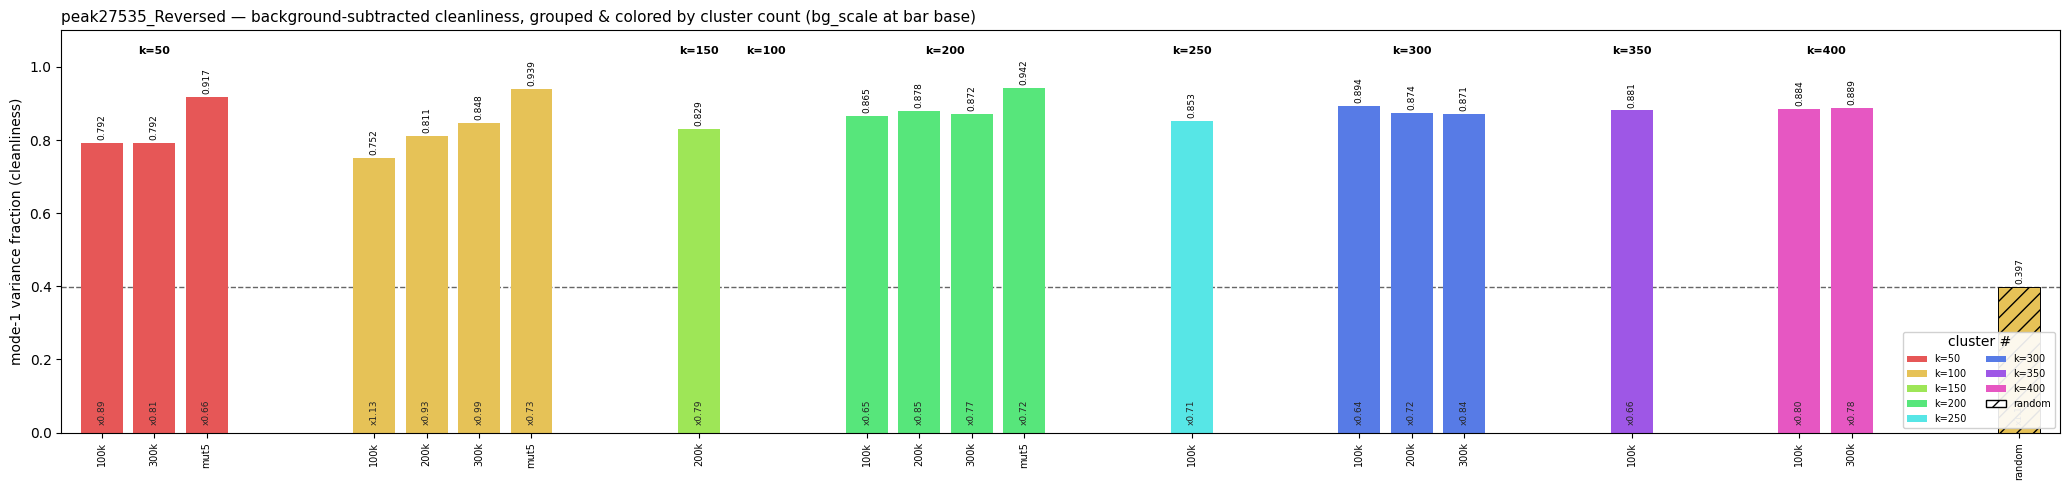

In [97]:
import colorsys
from matplotlib.patches import Patch

def kof(d):   return int(d["label"].split("_k")[-1])
def libof(d): return d["label"].split("_k")[0]

# group runs by cluster number k (same k adjacent, library sorted within); random baseline last
order  = sorted(results_bg, key=lambda d: (d["is_random"], kof(d), libof(d)))
ks     = sorted({kof(d) for d in order})
kcolor = {k: colorsys.hsv_to_rgb(i / len(ks), 0.62, 0.90) for i, k in enumerate(ks)}

# x positions with a wide gap between k-groups so group headers never collide
GAP = 2.2
xs, x, prevk = [], 0, None
for d in order:
    if prevk is not None and kof(d) != prevk: x += GAP
    xs.append(x); x += 1; prevk = kof(d)

fig, ax = plt.subplots(figsize=(max(7, 0.5 * x + 2), 5.0))
for xi, d in zip(xs, order):
    ax.bar(xi, d["cleanliness"], color=kcolor[kof(d)],
           hatch="//" if d["is_random"] else None,
           edgecolor="black" if d["is_random"] else "none", linewidth=0.7)
    ax.text(xi, d["cleanliness"] + 0.008, f"{d['cleanliness']:.3f}",
            ha="center", va="bottom", fontsize=6.5, rotation=90)
    ax.text(xi, 0.02, f"x{d['bg_scale']:.2f}", ha="center", va="bottom",
            fontsize=6.5, color="0.15", rotation=90)           # bg_scale at bar base
rand = next((d["cleanliness"] for d in order if d["is_random"]), None)
if rand is not None:
    ax.axhline(rand, color="0.4", lw=1, ls="--", zorder=0)

ax.set_xticks(xs)
ax.set_xticklabels([libof(d) for d in order], rotation=90, fontsize=7)
for k in ks:
    gx = [xi for xi, d in zip(xs, order) if kof(d) == k]
    ax.text(np.mean(gx), 1.03, f"k={k}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("mode-1 variance fraction (cleanliness)")
ax.set_ylim(0, 1.10)
ax.margins(x=0.01)
ax.legend(handles=[Patch(facecolor=kcolor[k], label=f"k={k}") for k in ks] +
                  [Patch(facecolor="white", edgecolor="black", hatch="//", label="random")],
          title="cluster #", fontsize=7, ncol=2, loc="lower right", framealpha=0.9)
ax.set_title(f"{REF_SEQ} — background-subtracted cleanliness, grouped & colored by cluster count "
             f"(bg_scale at bar base)", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_cluster_cleanliness_bgsub.png", dpi=150, bbox_inches="tight")
plt.show()

## 2b. Consensus mode (background-subtracted) as a sequence logo per run

Mode-1 of the background-subtracted maps = the cluster's shared *foreground* (motif structure
left after removing `bg_scale x background`). `bg_scale` annotated per run. Modes 1-3 for a
focal run follow.

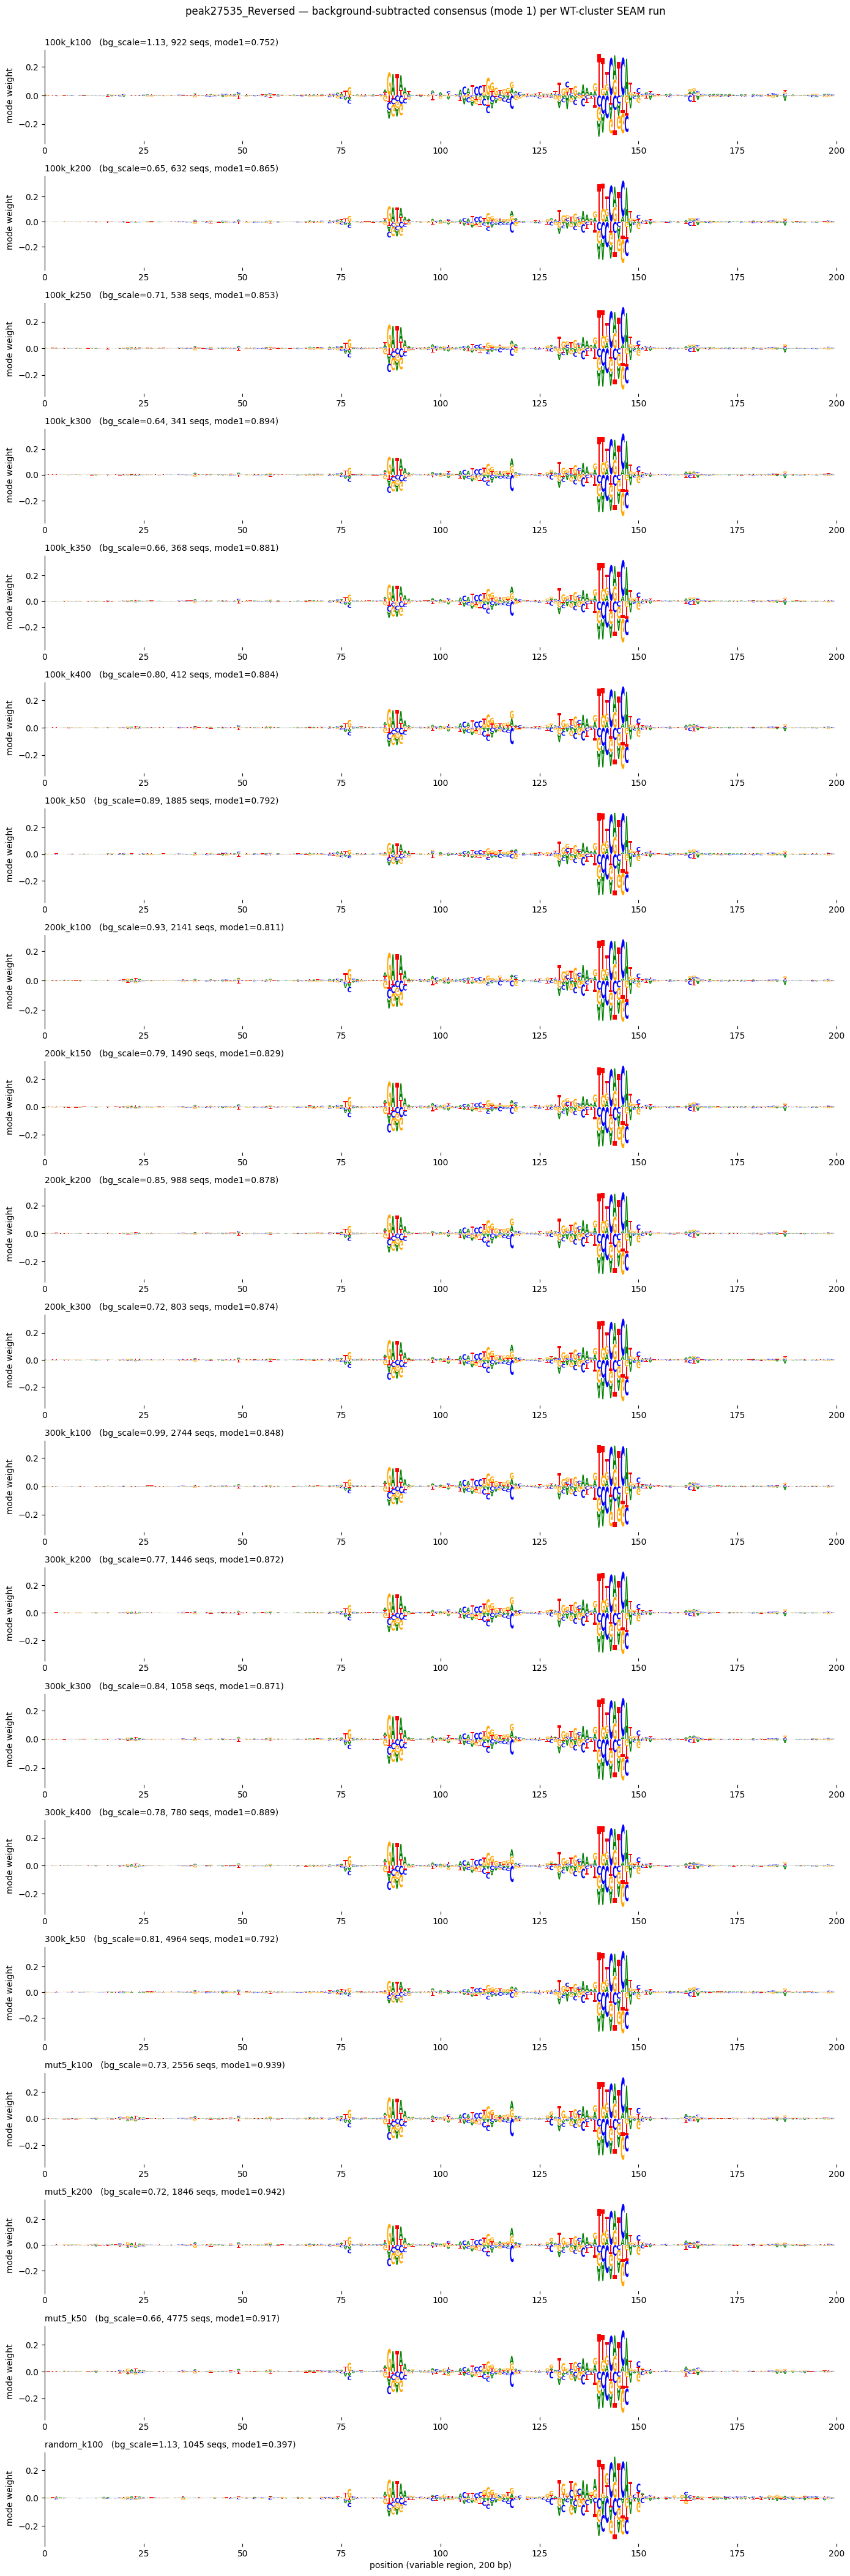

In [98]:
n = len(results_bg)
# sharex=False so every logo is on its own scale (fast_logo auto-fits y per panel)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.1 * n), sharex=False, squeeze=False)
for ax, d in zip(axes[:, 0], results_bg):
    fast_logo(d["modes"][0], ax)                               # mode-1 = consensus foreground map
    ax.set_title(f"{d['label']}   (bg_scale={d['bg_scale']:.2f}, {d['n_members']} seqs, "
                 f"mode1={d['cleanliness']:.3f})", loc="left", fontsize=10)
    ax.set_ylabel("mode weight")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — background-subtracted consensus (mode 1) per WT-cluster SEAM run",
             y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_consensus_mode_logos_bgsub.png", dpi=150, bbox_inches="tight")
plt.show()

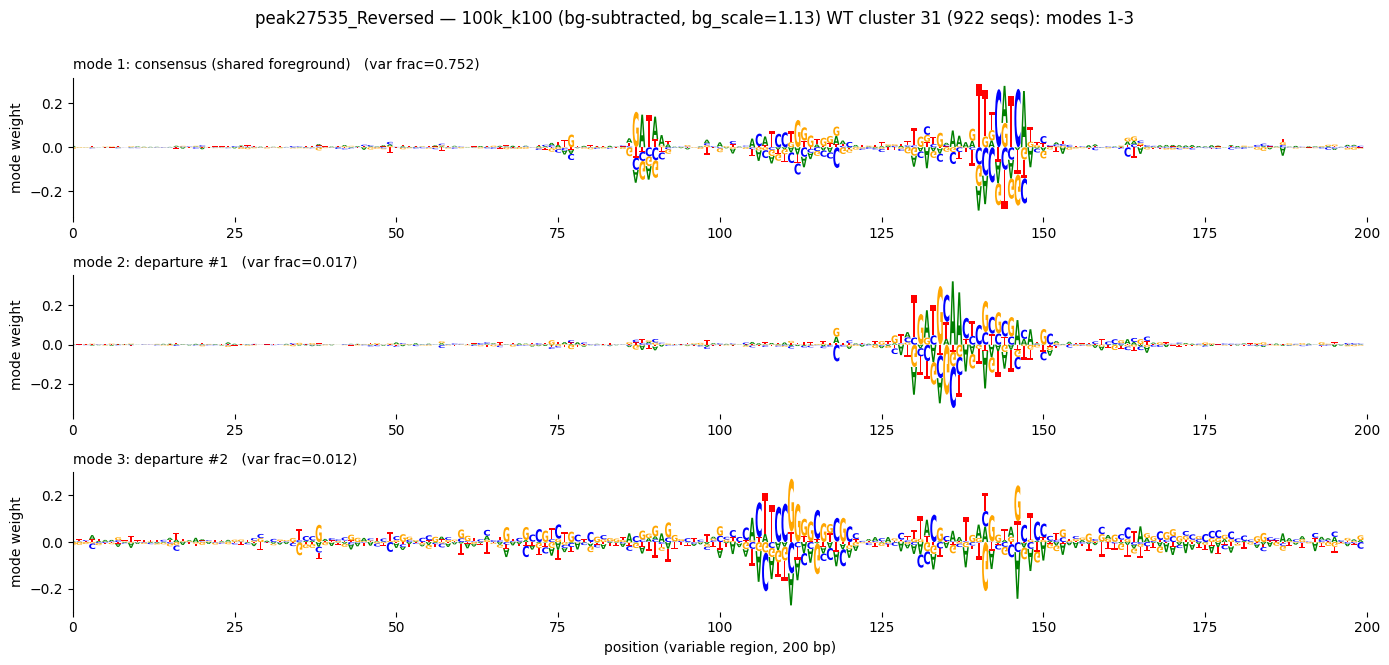

In [99]:
# consensus + leading departures for one focal run (bg-subtracted): modes 1-3
FOCUS = "100k_k100"
d = next(x for x in results_bg if x["label"] == FOCUS)

names = ["consensus (shared foreground)", "departure #1", "departure #2"]
fig, axes = plt.subplots(3, 1, figsize=(14, 6.6), sharex=False)   # each mode on its own scale
for ax, k in zip(axes, range(3)):
    fast_logo(d["modes"][k], ax)                               # mode k as (200,4)
    ax.set_title(f"mode {k+1}: {names[k]}   (var frac={d['frac'][k]:.3f})", loc="left", fontsize=10)
    ax.set_ylabel("mode weight")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — {FOCUS} (bg-subtracted, bg_scale={d['bg_scale']:.2f}) WT cluster "
             f"{d['wt_cluster']} ({d['n_members']} seqs): modes 1-3", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_{FOCUS}_modes123_bgsub.png", dpi=150, bbox_inches="tight")
plt.show()

best bg-subtracted run: mut5_k200  bg_scale=0.721  cleanliness=0.942


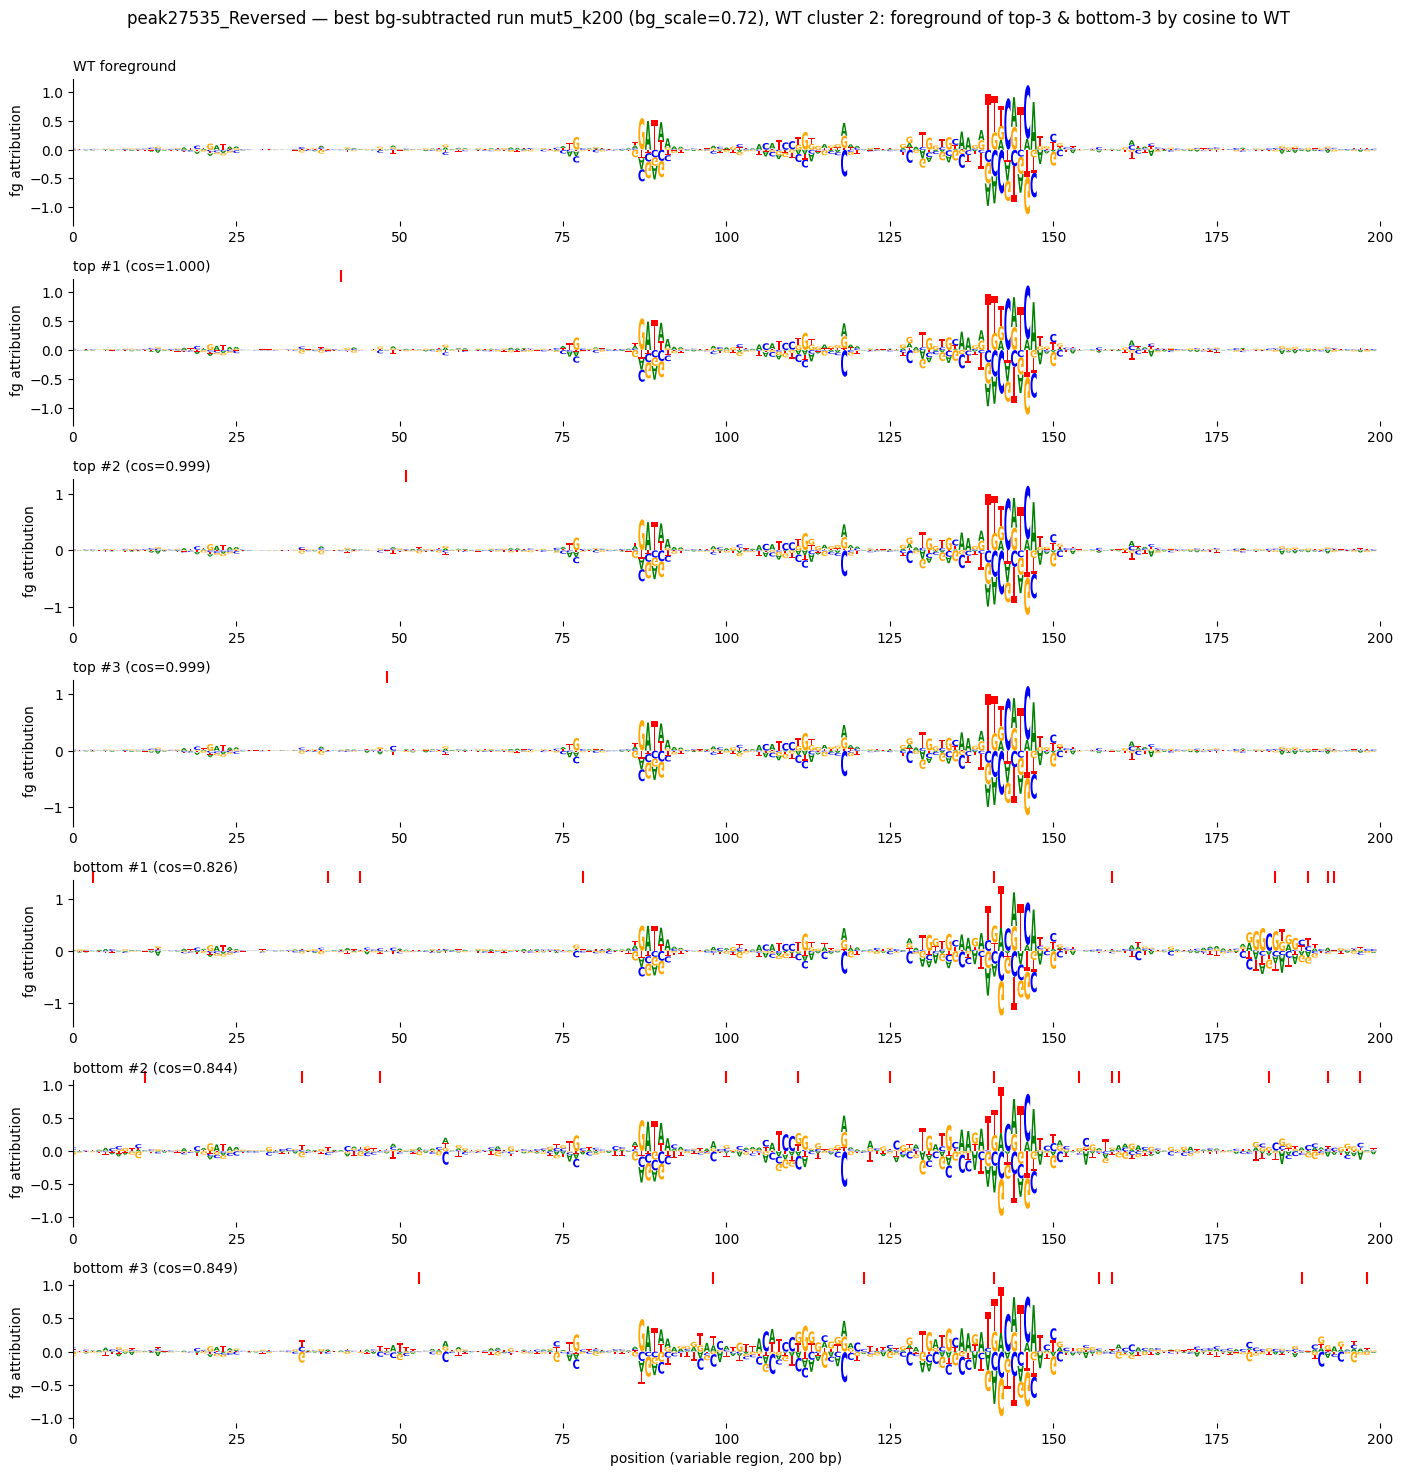

In [100]:
# FINAL (bg-subtracted): best run by bg-subtracted cleanliness -> top-3 & bottom-3 WT-cluster
# members by cosine sim to the WT foreground (ism_WT - scaled background).
best = max((d for d in results_bg if not d["is_random"]), key=lambda d: d["cleanliness"])
suf  = lib_suffix(best["fg_name"])
ISM_H5, LIB_H5 = R / f"ism{suf}" / f"{REF_SEQ}.h5", R / f"mutagenesis_lib{suf}" / f"{REF_SEQ}.h5"
bgs  = np.load(R / best["fg_name"] / REF_SEQ / "average_background_scaled.npy")   # WT-cluster scaled background
print(f"best bg-subtracted run: {best['label']}  bg_scale={best['bg_scale']:.3f}  cleanliness={best['cleanliness']:.3f}")

labels     = np.load(R / best["fg_name"] / REF_SEQ / "cluster_labels.npy")
wt_cluster = int(labels[0])
with h5py.File(ISM_H5) as f:
    attributions = f["ism_centered"][:]                       # (N, 200, 4)
with h5py.File(LIB_H5) as f:
    var_seqs = f["sequences"][:, 15:215, :]                   # (N, 200, 4)

fg     = attributions - bgs                                   # background-subtracted foreground maps
wt_fg  = fg[0]                                                # WT foreground
wt_int = var_seqs[0].argmax(-1)
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)

members = np.where(labels == wt_cluster)[0]
members = members[is_variant[members]]
flat    = fg[members].reshape(len(members), -1)
cos     = flat @ wt_fg.ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(wt_fg))
order   = np.argsort(cos)

top    = members[order[-3:][::-1]]; tcos = cos[order[-3:][::-1]]
bottom = members[order[:3]];        bcos = cos[order[:3]]
panels  = [("WT foreground", 0, False)]
panels += [(f"top #{i+1} (cos={c:.3f})",    int(idx), True) for i, (idx, c) in enumerate(zip(top, tcos))]
panels += [(f"bottom #{i+1} (cos={c:.3f})", int(idx), True) for i, (idx, c) in enumerate(zip(bottom, bcos))]

# sharex=False so every logo is on its own scale
fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.1 * len(panels)), sharex=False, squeeze=False)
for ax, (title, idx, tick) in zip(axes[:, 0], panels):
    fast_logo(fg[idx], ax)                                     # background-subtracted map, full 4 channels
    if tick:
        mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0]
        ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
                markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("fg attribution")
    ax.set_xlim(0, 200)
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
axes[-1, 0].set_xlabel("position (variable region, 200 bp)")
fig.suptitle(f"{REF_SEQ} — best bg-subtracted run {best['label']} (bg_scale={best['bg_scale']:.2f}), "
             f"WT cluster {wt_cluster}: foreground of top-3 & bottom-3 by cosine to WT", y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(OUT / f"{REF_SEQ}_bestrun_bgsub_{best['label']}_top_bottom3.png", dpi=150, bbox_inches="tight")
plt.show()